<div align="center">
    <img src="recursos/img/logoitqv1.jpg" width="200">
</div>

0.1 01PAO26-26 -Transformaciones

<p align="center">
  <img src="recursos/img/python_logo.png" width="200">
</p>

**Nombre:** Kerly Pilco

**Fecha:** 14/07/2026
**Repositorio:** [Link del repositorio de GitHub]
(https://github.com/kelapilco/machine-1-2026-nocturno.git)

In [2]:
import os
print(os.getcwd())

C:\Users\Lenovo\Desktop\machinelerning\practicas


Dimensiones de la imagen: (256, 256, 3)


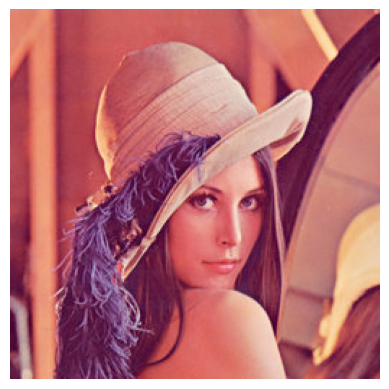

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Leer la imagen
img = cv2.imread("images/Lena_RGB.png")

# Verificar que se cargó correctamente
if img is None:
    print("No se pudo cargar la imagen.")
else:
    print("Dimensiones de la imagen:", img.shape)

    # Convertir de BGR (OpenCV) a RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [4]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

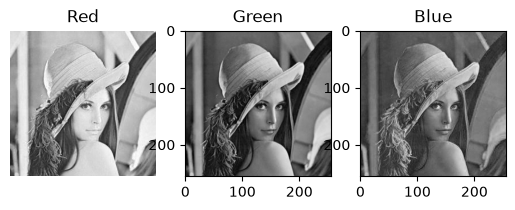

In [5]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'), ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

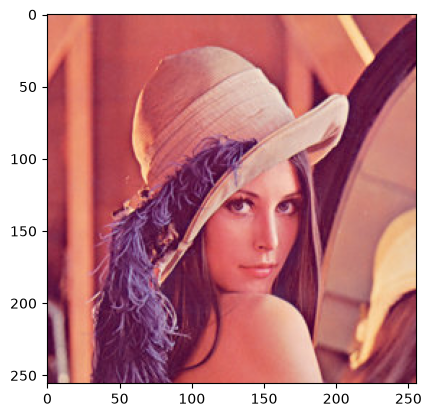

In [6]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()


**0.0.1 TRANSFORMACIONES DE INTENSIDAD**

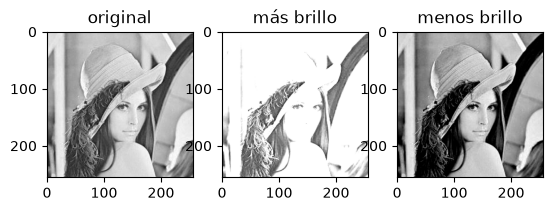

In [8]:
# CAMBIO DE BRILLO
img = cv2.imread("images/Lena_RGB.png")
img = img[:,:,2] # red color
mas_brillo = 100
menos_brillo = -100
mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de␣"+"
menos_brillo_img = cv2.add(img, menos_brillo)
fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()


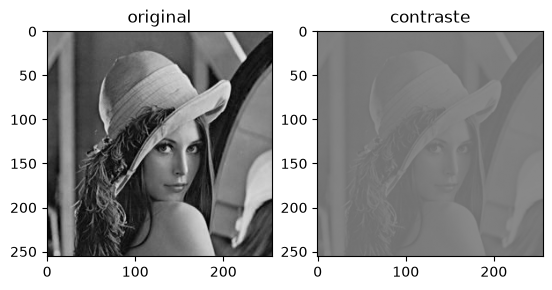

In [11]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread("images/Lena_RGB.png")
img = img[:,:,1] # canal verde
contraste = -100
f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)
contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

**0.0.2 CONVERSIONES DEL ESPACIO DE COLOR**

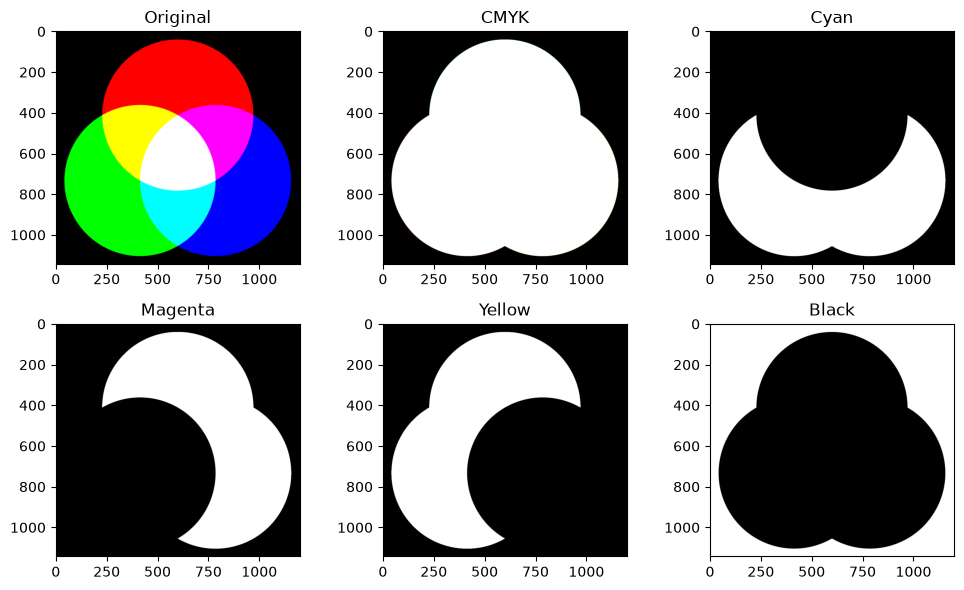

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Leer imagen
img = io.imread("images/colores.png")

rgb = img.copy()
rgb_p = rgb.astype(np.float32) / 255

with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)

    C = (1 - rgb_p[:, :, 0] - K) / (1 - K)
    M = (1 - rgb_p[:, :, 1] - K) / (1 - K)
    Y = (1 - rgb_p[:, :, 2] - K) / (1 - K)

    # Evitar NaN cuando K = 1
    C[np.isnan(C)] = 0
    M[np.isnan(M)] = 0
    Y[np.isnan(Y)] = 0

CMYK = (np.dstack((C, M, Y, K)) * 255).astype(np.uint8)

C, M, Y, K = cv2.split(CMYK)

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

ax[0, 0].imshow(img)
ax[0, 0].set_title("Original")

ax[0, 1].imshow(CMYK)
ax[0, 1].set_title("CMYK")

ax[0, 2].imshow(C, cmap="gray")
ax[0, 2].set_title("Cyan")

ax[1, 0].imshow(M, cmap="gray")
ax[1, 0].set_title("Magenta")

ax[1, 1].imshow(Y, cmap="gray")
ax[1, 1].set_title("Yellow")

ax[1, 2].imshow(K, cmap="gray")
ax[1, 2].set_title("Black")

plt.tight_layout()
plt.show()


In [21]:
# Otras conversiones
from skimage import io
img = cv2.imread("images/colores.png")

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # gray-scale

HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # (H)ue, (S)aturation and (V)alue

Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab) # (L)uminosidad, a-b colores␣complementarios

YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb) # Y-Luma, Cr-Cb crominancia rojo␣y azul

**0.0.3 TRANSFORMACIONES GEOMÉTRICAS**

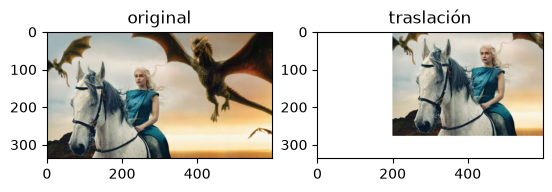

In [22]:
# TRASLACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape

M = np.float32([[1,0,200],[0,1,-60]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

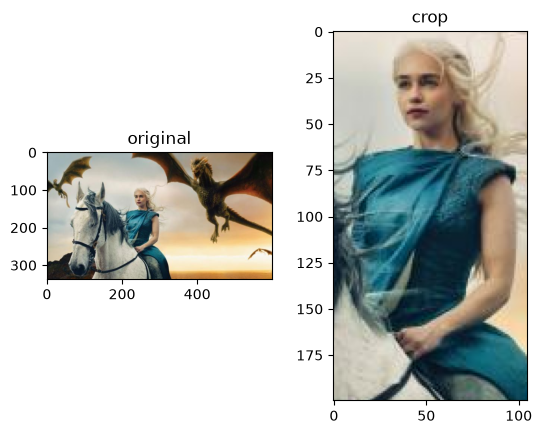

In [23]:
# CROPPING
img = io.imread('images/GOT.png')
new_img = img[90:290, 200:305]
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

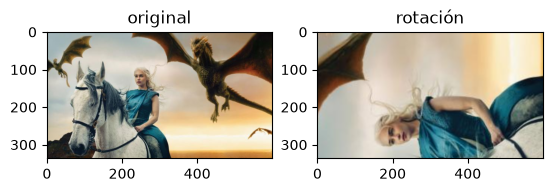

In [24]:
# ROTACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=90,scale=2) # Defino la␣matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

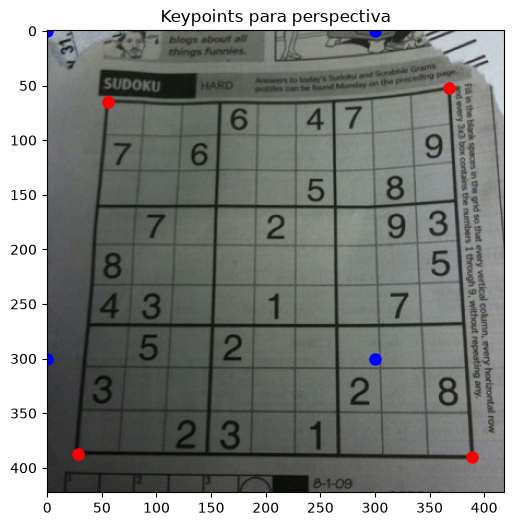

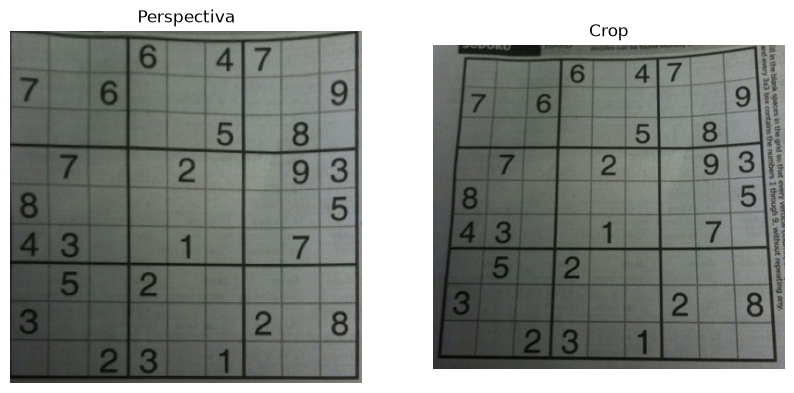

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img = cv2.imread("images/sudoku.png")

# Verificar que la imagen exista
if img is None:
    print("No se pudo cargar la imagen.")
else:
    # Convertir de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    rows, cols, ch = img.shape

    # Puntos originales
    pts1 = np.float32([
        [56, 65],
        [368, 52],
        [28, 387],
        [389, 390]
    ])

    # Puntos destino
    pts2 = np.float32([
        [0, 0],
        [300, 0],
        [0, 300],
        [300, 300]
    ])

    # Mostrar imagen y puntos
    plt.figure(figsize=(6,6))
    plt.imshow(img)

    for i in range(4):
        plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=8)
        plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=8)

    plt.title("Keypoints para perspectiva")
    plt.axis("on")
    plt.show()

    # Matriz de transformación
    M = cv2.getPerspectiveTransform(pts1, pts2)

    # Aplicar transformación
    pers = cv2.warpPerspective(img, M, (305, 305))

    # Recorte
    crop = img[50:400, 20:400]

    # Mostrar resultados
    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    ax[0].imshow(pers)
    ax[0].set_title("Perspectiva")
    ax[0].axis("off")

    ax[1].imshow(crop)
    ax[1].set_title("Crop")
    ax[1].axis("off")

    plt.show()

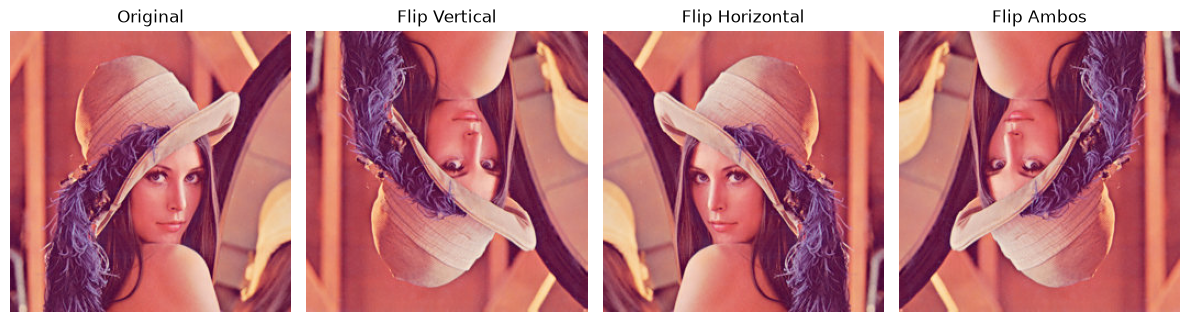

In [26]:
import cv2
import matplotlib.pyplot as plt

# Leer la imagen
img = cv2.imread("images/Lena_RGB.png")

# Verificar que la imagen exista
if img is None:
    print("No se pudo cargar la imagen.")
else:
    # Convertir de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Voltear la imagen
    flipVertical = cv2.flip(img, 0)
    flipHorizontal = cv2.flip(img, 1)
    flipBoth = cv2.flip(img, -1)

    # Mostrar resultados
    fig, ax = plt.subplots(1, 4, figsize=(12, 4))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(flipVertical)
    ax[1].set_title("Flip Vertical")
    ax[1].axis("off")

    ax[2].imshow(flipHorizontal)
    ax[2].set_title("Flip Horizontal")
    ax[2].axis("off")

    ax[3].imshow(flipBoth)
    ax[3].set_title("Flip Ambos")
    ax[3].axis("off")

    plt.tight_layout()
    plt.show()